In [11]:
import numpy as np
import matplotlib.pyplot as plt
import capytaine as cpt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Load in Mesh

In [2]:
buoy_mesh = cpt.load_mesh("Buoy.STL")

### Initialize the Floating Body
This step converts the static 3D mesh into a mathematical boundary condition that the fluid solver can interact with. By wrapping it in `FloatingBody`, Capytaine automatically assigns the 6 Degrees of Freedom (DOFs) to the object, defining exactly how it can move when hit by waves:

**Translations (Linear Movement):**
* **Surge:** Forward/backward (X-axis)
* **Sway:** Left/right (Y-axis)
* **Heave:** Up/down (Z-axis)

**Rotations (Angular Movement):**
* **Roll:** Tilting side-to-side (around X-axis)
* **Pitch:** Tilting forward/backward (around Y-axis)
* **Yaw:** Spinning (around Z-axis)

In [10]:
buoy = cpt.FloatingBody( 
    mesh=buoy_mesh,
    name="buoy"
)

[22:09:52] WARNING          --> the mesh does not seem watertight although marked as closed...

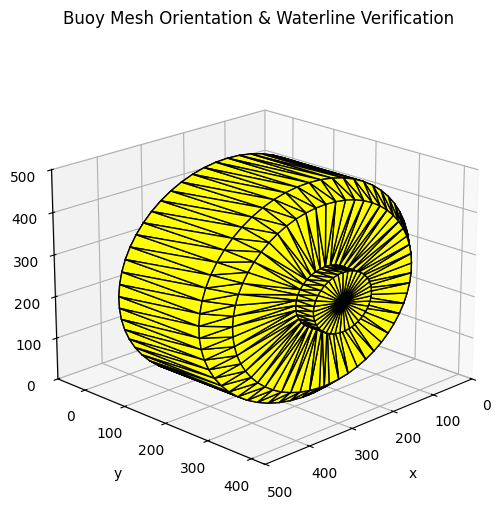

In [15]:
# Create a standard Matplotlib 3D canvas to verify new CAD alignment
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Force the grid and coordinate tick labels to show up
ax.set_axis_on() 
ax.grid(True)

# Add clear axis labels to verify Z is Vertical and 0 is the Waterline
ax.set_xlabel('X Axis (Meters)', fontsize=10, labelpad=10)
ax.set_ylabel('Y Axis (Meters)', fontsize=10, labelpad=10)
ax.set_zlabel('Z Axis (Meters - VERTICAL)', fontsize=10, labelpad=10)

# Set a camera angle looking slightly down and around the buoy
ax.view_init(elev=20, azim=45)

# Render the buoy inside our labeled canvas
buoy.show_matplotlib(ax=ax)

plt.title("Buoy Mesh Orientation & Waterline Verification", fontsize=12, pad=20)
plt.show()

In [4]:
# Print the RAW bounding box to see where the CAD origin is
print(f"RAW Mesh Bounding Box (Min x, y, z): {buoy.mesh.vertices.min(axis=0)} meters") #shold see some negative
print(f"RAW Mesh Bounding Box (Max x, y, z): {buoy.mesh.vertices.max(axis=0)} meters")
print(f"Number of total faces: {buoy.mesh.nb_faces}")

RAW Mesh Bounding Box (Min x, y, z): [0.09509921 0.         0.        ] meters
RAW Mesh Bounding Box (Max x, y, z): [500.89456177 360.         500.98968506] meters
Number of total faces: 608


### Extract the Wetted Surface
The boundary element solver only calculates pressure on the physical area where water touches the hull. This step mathematically slices off the dry portion above Z=0 (`immersed_part`) so the simulation runs accurately and efficiently.

In [5]:
# Extract only the wetted surface (everything below z=0)
buoy = buoy.immersed_part()

# Verify it cut correctly (Max z should now be exactly 0.0)
print(f"Wet Mesh Bounding Box (Min x, y, z): {buoy.mesh.vertices.min(axis=0)} meters")
print(f"Wet Mesh Bounding Box (Max x, y, z): {buoy.mesh.vertices.max(axis=0)} meters")

/Users/liamgaeuman/Desktop/MS-Project/python/buoyEnv/lib/python3.12/site-packages/capytaine/meshes/quality.py:354: RuntimeWarning: Mean of empty slice
  area_threshold = areas.mean() * float(rtol)
/Users/liamgaeuman/Desktop/MS-Project/python/buoyEnv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation minimum which has no identity

### Define the Environment & Build the Task Queue
Before running the simulation, we must build a queue of specific scenarios for the physics engine to solve. We do this by creating a list of individual `BEMProblem` tasks. Each task bundles the buoy geometry together with specific environmental conditions:

* **Depth:** Infinite (representing deep open water).
* **Wave Angle:** **0°** (only one angle is needed since the buoy is perfectly symmetrical).
* **Frequency:** A single frequency from our massive sweep of 200 data points (0.1 rad/s to 15.0 rad/s).

By looping through the frequencies, we generate 200 unique tasks ready to be solved. 

*Note: This high resolution and wide sweep are required for WEC-Sim. It ensures the software can calculate a stable Impulse Response Function (IRF) without mathematical gaps or "ghost" ringing, which is critical for generating clean synthetic data.*

In [ ]:
# 1. Generate a high-resolution array of 200 wave frequencies (rad/s)
# Sweeping from 0.1 to 15.0 rad/s to capture the "tails" for WEC-Sim's IRF math
omega_range = np.linspace(0.1, 15.0, 200)

# 2. Build the task queue (a list of all 200 scenarios)
tasks = [
    cpt.BEMProblem(
        body=buoy,
        water_depth=np.inf,        # Deep water assumption
        omega=w,                   # Current frequency in the loop
        wave_direction=0.0         # 0 radians (head-on waves)
    )
    for w in omega_range
]

# Verify the setup
print(f"Successfully generated {len(tasks)} high-resolution test conditions for the WEC-Sim pipeline.")

### Run the BEM Solver
This step initializes Capytaine's physics engine and processes our queue of 200 tasks. For every frequency in the queue, the solver computes the core hydrodynamic forces acting on the wetted hull. 

The solver outputs a `results` dataset containing the foundational physics data (the "rulebook") required by WEC-Sim. This output is divided into two primary categories:

* **Radiation Data (Buoy moving in still water):**
    * **Added Mass:** The virtual weight added to the system as the buoy drags surrounding water along with its movement.
    * **Radiation Damping:** The energy the buoy loses to the environment by generating its own surface ripples as it oscillates.
* **Diffraction & Excitation Data (Waves hitting a stationary buoy):**
    * **Excitation Force:** The total hydrodynamic force exerted on the hull by incoming waves.
    * **Froude-Krylov Force:** The raw pressure exerted by the undisturbed wave profile.
    * **Diffraction Force:** The additional force generated as the waves bend, scatter, and distort around the physical hull.

*Note: Capytaine compiles these raw radiation and diffraction coefficients directly into a Python `results` list. WEC-Sim will ingest this file later to simulate real-world, time-domain movements. Because the solver is executing 200 high-resolution tasks to ensure data density for WEC-Sim, this cell will require a few minutes to finish computing.*

In [ ]:
# 1. Initialize the BEM solver
solver = cpt.BEMSolver()

# 2. Crunch the math for all 200 scenarios
# Capytaine will automatically utilize your CPU's available cores to speed this up
results = solver.solve_all(tasks)

# 3. Verify the solver finished successfully
print(f"Successfully computed {len(results)} hydrodynamic results")

### Hydrodynamic Coefficients Sweep (Sanity Check)
Plots the primary hydrodynamic coefficients across the 200 frequency points. 
* **Smooth Curves:** Confirm a stable, high-resolution simulation ready for time-domain modeling.
* **Erratic Spikes:** Indicate numerical resonance or mesh errors that must be resolved before proceeding.

We isolate the **Heave** (vertical bobbing) components for **Added Mass** and **Radiation Damping**.

In [ ]:
# 1. Gather results into a temporary dataset to extract plotting vectors
plot_ds = cpt.assemble_dataset(results)

omega_vals = plot_ds.coords['omega'].values
added_mass_heave = plot_ds['added_mass'].sel(radiating_dof='heave', requested_dof='heave').values
damping_heave = plot_ds['radiation_damping'].sel(radiating_dof='heave', requested_dof='heave').values

# 2. Construct Dual-Y Axis Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Added Mass (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Wave Frequency ($\omega$ [rad/s])', fontsize=11)
ax1.set_ylabel('Added Mass (Heave)', color=color, fontsize=11)
ax1.plot(omega_vals, added_mass_heave, color=color, linewidth=2, label='Added Mass')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot Radiation Damping (Right Axis)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Radiation Damping (Heave)', color=color, fontsize=11)
ax2.plot(omega_vals, damping_heave, color=color, linewidth=2, linestyle='--', label='Radiation Damping')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Capytaine Hydrodynamic Coefficients vs. Frequency', fontsize=13, pad=15)
fig.tight_layout()
plt.show()

### Export Results to BEMIO (HDF5 File)

In [ ]:
import capytaine.io.bemio as bemio

# 1. Gather all individual results into a single dataset object
dataset = cpt.assemble_dataset(results)

# 2. Export the dataset to the standard WEC-Sim .h5 format
# Change 'lake_superior_buoy.h5' to whatever you want to name your file
bemio.write_hdf5(dataset, filename='lake_superior_buoy.h5')

print("exported Capytaine results to 'lake_superior_buoy.h5'")
